# Traffic-signal-control experiment

This notebook compares simple baselines, MAPPO, and reward-sharing MAPPO on a network.

In [12]:
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content/marl-tsc")

    if not ROOT.exists():
        subprocess.run(["git", "clone", "https://github.com/abergh18/marl-tsc.git", str(ROOT)], check=True)

    subprocess.run(["apt-get", "update"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "sumo", "sumo-tools"],
        check=True,
    )
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "-r", str(ROOT / "requirements.txt"),
    ], check=True)

    os.environ["SUMO_HOME"] = "/usr/share/sumo"
    sys.path.insert(0, "/usr/share/sumo/tools")

else:
    # Run VS Code from somewhere inside the marl-tsc repository.
    ROOT = next(
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "src" / "marl_tsc").exists()
    )

# Make /src/marl_tsc importable.
sys.path.insert(0, str(ROOT / "src"))

# Relative project paths now work consistently.
os.chdir(ROOT)

print(f"Running in {'Colab' if IN_COLAB else 'VS Code'} from {ROOT}")

Running in VS Code from c:\Code\marl-tsc


In [13]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

from marl_tsc.baselines import fixed_time_actions, random_actions
from marl_tsc.mappo import train_mappo
from marl_tsc.network_types import CityNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import (
    evaluate_policies,
    export_policy_replay,
    evaluation_results_table,
    plot_training_histories,
)

## 1. Configure and generate the simulation

In [ ]:
SEED = 42
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS = 120_000
EVALUATION_EPISODES = 3

# The same environment settings are used for training, evaluation, and replay.
ENV_KWARGS = {
    "green_phase_count": None,
    "min_green_seconds": 10,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.1,
    "collect_global_metrics": True,
    "global_metric_interval": 10,
}

OUTPUT_DIR = ROOT / "outputs"
SIMULATION_DIR = OUTPUT_DIR / "simulation"
network = CityNetwork(city_name="Lancaster, UK", radius=500)
generator = SimulationGenerator(
    output_dir=SIMULATION_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=3,
    seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Traffic-light agent count: {len(traffic_light_ids)}")

Generated SUMO config: C:\Code\marl-tsc\outputs\simulation\config.sumocfg
Traffic-light agent count: 5


## 2. Train MAPPO policies

The reward-sharing policy has an extra sharing action during training. Both policies are evaluated using the same traffic metrics.

In [7]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=False,
)

[MAPPO] Episode 1 | Return: -90.62 | Total Steps: 600
[MAPPO] Episode 2 | Return: -65.56 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -91.08 | Total Steps: 1800
[MAPPO] Episode 4 | Return: -77.28 | Total Steps: 2400
[MAPPO] Episode 5 | Return: -108.84 | Total Steps: 3000
[MAPPO] Episode 6 | Return: -103.87 | Total Steps: 3600
[MAPPO] Episode 7 | Return: -108.83 | Total Steps: 4200
[MAPPO] Episode 8 | Return: -91.72 | Total Steps: 4800
[MAPPO] Episode 9 | Return: -72.77 | Total Steps: 5400
[MAPPO] Episode 10 | Return: -101.99 | Total Steps: 6000
[MAPPO] Episode 11 | Return: -87.33 | Total Steps: 6600
[MAPPO] Episode 12 | Return: -91.74 | Total Steps: 7200
[MAPPO] Episode 13 | Return: -87.76 | Total Steps: 7800
[MAPPO] Episode 14 | Return: -100.09 | Total Steps: 8400
[MAPPO] Episode 15 | Return: -84.47 | Total Steps: 9000
[MAPPO] Episode 16 | Return: -74.53 | Total Steps: 9600
[MAPPO] Episode 17 | Return: -80.84 | Total Steps: 10200
[MAPPO] Episode 18 | Return: 

In [8]:
reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=True,
)

[MAPPO] Episode 1 | Return: -115.58 | Total Steps: 600
[MAPPO] Episode 2 | Return: -99.58 | Total Steps: 1200
[MAPPO] Episode 3 | Return: -81.48 | Total Steps: 1800
[MAPPO] Episode 4 | Return: -95.16 | Total Steps: 2400
[MAPPO] Episode 5 | Return: -68.00 | Total Steps: 3000
[MAPPO] Episode 6 | Return: -112.90 | Total Steps: 3600
[MAPPO] Episode 7 | Return: -113.96 | Total Steps: 4200
[MAPPO] Episode 8 | Return: -104.63 | Total Steps: 4800
[MAPPO] Episode 9 | Return: -82.95 | Total Steps: 5400
[MAPPO] Episode 10 | Return: -97.39 | Total Steps: 6000
[MAPPO] Episode 11 | Return: -104.01 | Total Steps: 6600
[MAPPO] Episode 12 | Return: -143.15 | Total Steps: 7200
[MAPPO] Episode 13 | Return: -74.82 | Total Steps: 7800
[MAPPO] Episode 14 | Return: -70.88 | Total Steps: 8400
[MAPPO] Episode 15 | Return: -104.22 | Total Steps: 9000
[MAPPO] Episode 16 | Return: -79.80 | Total Steps: 9600
[MAPPO] Episode 17 | Return: -74.73 | Total Steps: 10200
[MAPPO] Episode 18 | Return: -93.19 | Total Steps:

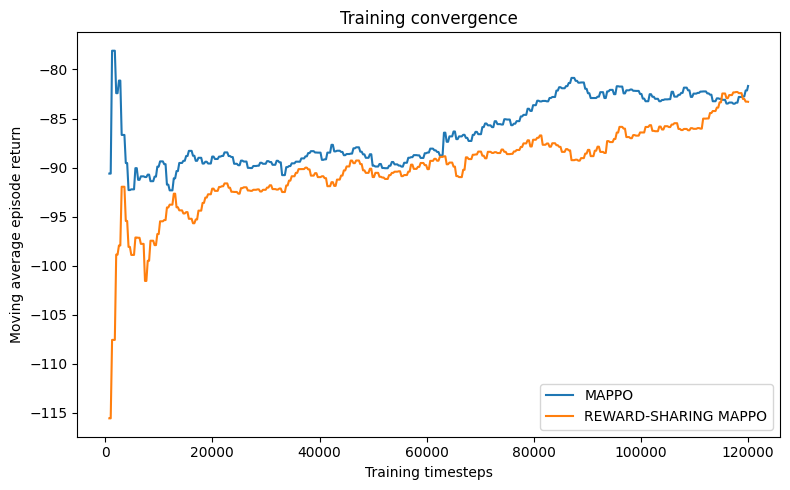

In [9]:
fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
})
plt.show()

## 3. Export a SUMO replay

In [10]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=reward_sharing_model,
    output_dir=OUTPUT_DIR / "replays" / "reward_sharing_mappo",
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)
print(f"Open this file in the SUMO GUI: {replay_config}")

Open this file in the SUMO GUI: C:\Code\marl-tsc\outputs\replays\reward_sharing_mappo\replay.sumocfg


## 4. Compare all policies

Every policy uses the same evaluation episodes, seeds, and environment settings.

In [11]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
}

policy_results = evaluate_policies(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policies=policies,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)

display(evaluation_results_table(policy_results))

Evaluating Random
Finished Evaluation Episode 1/3 - Total Reward: -382.51
Finished Evaluation Episode 2/3 - Total Reward: -425.39
Finished Evaluation Episode 3/3 - Total Reward: -455.01
Evaluating Fixed-Time
Finished Evaluation Episode 1/3 - Total Reward: -390.92
Finished Evaluation Episode 2/3 - Total Reward: -376.30
Finished Evaluation Episode 3/3 - Total Reward: -399.18
Evaluating MAPPO
Finished Evaluation Episode 1/3 - Total Reward: -1511.80
Finished Evaluation Episode 2/3 - Total Reward: -1287.17
Finished Evaluation Episode 3/3 - Total Reward: -1310.31
Evaluating Reward-sharing MAPPO
Finished Evaluation Episode 1/3 - Total Reward: -1226.83
Finished Evaluation Episode 2/3 - Total Reward: -1289.81
Finished Evaluation Episode 3/3 - Total Reward: -1597.27


,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-420.970667,0.258815,4.333333,6.079356,199.333333,1977.221236,945.333333,779.000000
1,Fixed-Time,-388.799000,0.326417,5.333333,4.700405,88.000000,1558.860455,953.000000,363.000000
2,MAPPO,-1369.759667,0.492231,4.333333,47.997555,468.666667,55944.531882,701.666667,408.333333
3,Reward-sharing MAPPO,-1371.302667,0.496657,5.000000,49.185960,399.666667,57721.705822,696.333333,411.666667
